In [7]:
# mixed pixels can bring different signatures 
# so indices are an indicator only
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio

b2 = rasterio.open('B2.tif')
b3 = rasterio.open('B3.tif')
b4 = rasterio.open('B4.tif')
b8 = rasterio.open('B8.tif')
b11 = rasterio.open('B11.tif')
print("Blue: ", b2.res, " No data", b3.nodata)
print("NIR:  ",b8.res, " No data", b3.nodata)
print("Green:", b3.res, " No data", b3.nodata)
print("SWIR: ", b11.res," No data",b11.nodata)


Blue:  (10.0, 10.0)  No data 65535.0
NIR:   (10.0, 10.0)  No data 65535.0
Green: (10.0, 10.0)  No data 65535.0
SWIR:  (20.0, 20.0)  No data 65535.0


In [13]:
red = b4.read(1).astype(np.float32)
nir = b8.read(1).astype(np.float32)

ndvi = (nir - red) / (nir + red)

print(" NDVI image shape is :" , ndvi.shape)


#numpy has a masked array system
red = np.ma.masked_equal(red, -99999)
nir = np.ma.masked_equal(nir, -99999)


 NDVI image shape is : (2019, 1426)


In [14]:
plt.figure(figsize=(8, 7))

<Figure size 800x700 with 0 Axes>

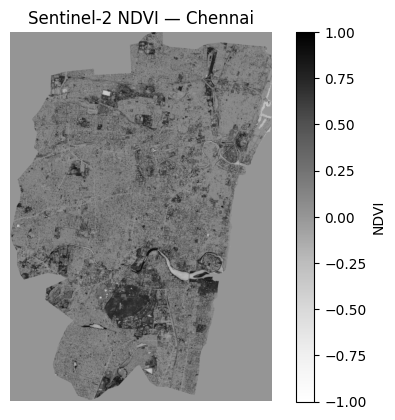

In [17]:
plt.imshow(
    ndvi,
    cmap= "Greys", #"RdYlGn",
    vmin=-1,
    vmax=1
)
plt.colorbar(label="NDVI")
plt.title("Sentinel-2 NDVI — Chennai")
plt.axis("off")
plt.show()

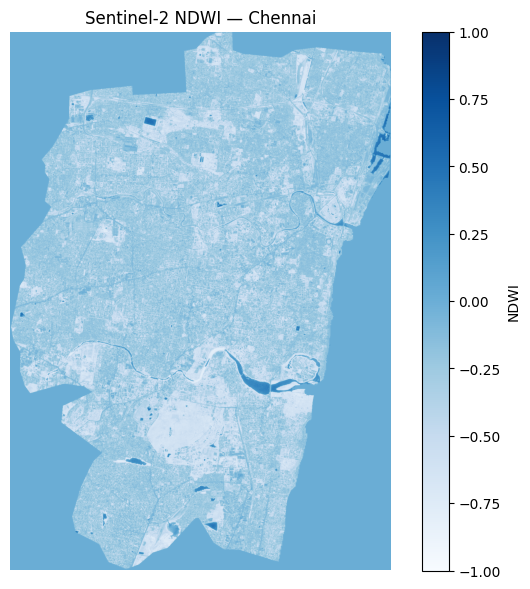

In [18]:
#NDWI
green = b3.read(1).astype("float32")
nir = b8.read(1).astype("float32")

green = np.ma.masked_equal(green, -99999)
nir = np.ma.masked_equal(nir, -99999)

ndwi = (green - nir) / (green + nir)

plt.figure(figsize=(8, 7))

plt.imshow(
    ndwi,
    cmap="Blues",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="NDWI")
plt.title("Sentinel-2 NDWI — Chennai")
plt.axis("off")
plt.show()

In [21]:
# For NBR - resample B11

from rasterio.warp import reproject
from rasterio.enums import Resampling
swir = b11.read(1).astype("float32")

swir_resampled = np.empty(
    (b8.height, b8.width),
    dtype="float32"
)
reproject(
    source=swir,
    destination=swir_resampled,
    src_transform=b11.transform,
    src_crs=b11.crs,
    dst_transform=b8.transform,
    dst_crs=b8.crs,
    src_nodata=-99999,
    dst_nodata=-99999,
    resampling=Resampling.bilinear
)





(array([[65535., 65535., 65535., ..., 65535., 65535., 65535.],
        [65535., 65535., 65535., ..., 65535., 65535., 65535.],
        [65535., 65535., 65535., ..., 65535., 65535., 65535.],
        ...,
        [65535., 65535., 65535., ..., 65535., 65535., 65535.],
        [65535., 65535., 65535., ..., 65535., 65535., 65535.],
        [65535., 65535., 65535., ..., 65535., 65535., 65535.]],
       dtype=float32),
 Affine(10.0, 0.0, 409930.0,
        0.0, -10.0, 1452090.0))

In [22]:
print("B8 shape:", b8.read(1).shape)
print("Resampled B11 shape:", swir_resampled.shape)

swir_resampled = np.ma.masked_equal(
    swir_resampled,
    -99999
)

B8 shape: (2019, 1426)
Resampled B11 shape: (2019, 1426)


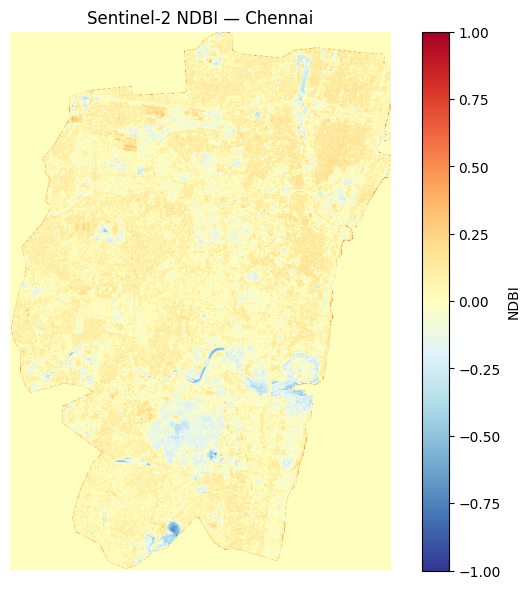

In [23]:
#NDBI
nir = b8.read(1).astype("float32")

nir = np.ma.masked_equal(
    nir,
    -99999
)

ndbi = (
    swir_resampled - nir
) / (
    swir_resampled + nir
)


plt.figure(figsize=(8, 7))

plt.imshow(
    ndbi,
    cmap="RdYlBu_r",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="NDBI")

plt.title("Sentinel-2 NDBI — Chennai")

plt.axis("off")

plt.show()

In [27]:
# EVI
nir = b8.read(1).astype("float32")

nir = np.ma.masked_equal(
    nir,
    -99999
)


red  = b4.read(1).astype("float32")

red  = np.ma.masked_equal(
    red,
    -99999
)



blue = b2.read(1).astype("float32")

blue  = np.ma.masked_equal(
    blue,
    -99999
)



evi = 2.5 * ((nir-red)/ (nir+(6*red)-(7.5*blue)+1))



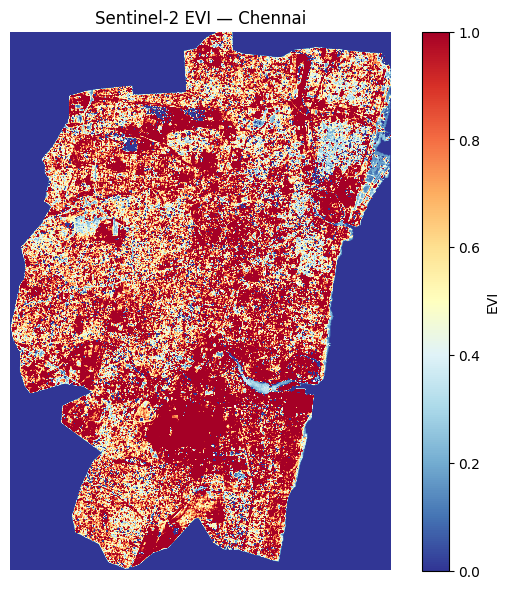

In [32]:
plt.figure(figsize=(8, 7))

plt.imshow(
    evi,
    cmap=  "RdYlBu_r",#"YlGn", #"RdYlBu_r",
    vmin=-1.0,
    vmax=1.0
)

plt.colorbar(label="EVI")

plt.title("Sentinel-2 EVI — Chennai")

plt.axis("off")

plt.show()

In [36]:
# NDMI
# NDMI = NIR-SWIR / (NIR+SWIR)

nir = b8.read(1).astype("float32")

nir = np.ma.masked_equal(
    nir,
    -99999
)


swir  = b11.read(1).astype("float32")

swir = np.ma.masked_equal(
    swir,
    -99999
)


# resample swir band





In [37]:
from rasterio.warp import reproject
from rasterio.enums import Resampling


swir_resampled = np.empty(
    (b8.height, b8.width),
    dtype="float32"
)
reproject(
    source=swir,
    destination=swir_resampled,
    src_transform=b11.transform,
    src_crs=b11.crs,
    dst_transform=b8.transform,
    dst_crs=b8.crs,
    src_nodata=-99999,
    dst_nodata=-99999,
    resampling=Resampling.bilinear
)



(array([[65535., 65535., 65535., ..., 65535., 65535., 65535.],
        [65535., 65535., 65535., ..., 65535., 65535., 65535.],
        [65535., 65535., 65535., ..., 65535., 65535., 65535.],
        ...,
        [65535., 65535., 65535., ..., 65535., 65535., 65535.],
        [65535., 65535., 65535., ..., 65535., 65535., 65535.],
        [65535., 65535., 65535., ..., 65535., 65535., 65535.]],
       dtype=float32),
 Affine(10.0, 0.0, 409930.0,
        0.0, -10.0, 1452090.0))

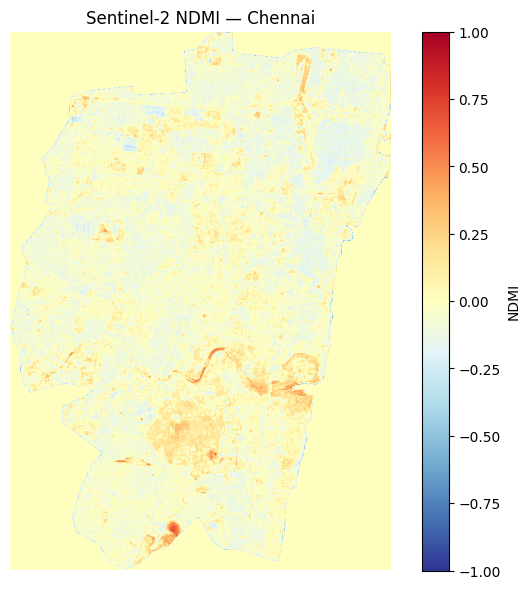

In [41]:
ndmi = (nir - swir_resampled )/ (nir + swir_resampled)


plt.figure(figsize=(8, 7))

plt.imshow(
    ndmi,
    cmap= "RdYlBu_r",#"RdYlGn" , # "YlGn", #"RdYlBu_r",
    vmin=-1.0,
    vmax=1.0
)

plt.colorbar(label="NDMI")

plt.title("Sentinel-2 NDMI — Chennai")

plt.axis("off")

plt.show()